In [2]:
import torch
import torch.nn as nn
import zipfile
import gdown
import os
from torch.utils.data import Subset, DataLoader, Dataset
from sklearn.model_selection import train_test_split
from torchvision.transforms import Resize
from torchvision.io import read_image
import matplotlib.pyplot as plt
from MLP import *
from torchsummary import summary

In [3]:
Folder = 'data/'
ID_FILE = '1MiNzagnzW-scHQgx3Mku1KUuPaJQ4TBQ'
FILE_NAME = 'FER-2013.zip'

In [4]:
os.makedirs(Folder,exist_ok=True)

# Tải DL và giải nén DL

In [5]:
gdown.download(id = ID_FILE, output= FILE_NAME)

Downloading...
From (original): https://drive.google.com/uc?id=1MiNzagnzW-scHQgx3Mku1KUuPaJQ4TBQ
From (redirected): https://drive.google.com/uc?id=1MiNzagnzW-scHQgx3Mku1KUuPaJQ4TBQ&confirm=t&uuid=bc8e0599-8fd3-42fa-bcd8-3af4fffb0a8b
To: d:\Exercise-Week3-Module-5\FER-2013.zip
100%|██████████| 63.3M/63.3M [00:05<00:00, 10.9MB/s]


'FER-2013.zip'

In [6]:
# Giải nén file FER-2013.zip
with zipfile.ZipFile('FER-2013.zip','r') as zip_ref:
    zip_ref.extractall(Folder)

In [7]:

train_dir = 'data/train'
test_dir = 'data/test'

# Thiêt lập 2 dictionary để ánh xạ từ nhãn -> index và từ index -> nhãn
classes = os.listdir(train_dir)
print(classes)
label2idx = {label:idx for idx, label in enumerate(classes)}
print(label2idx)
idx2label = {idx:label for label, idx in label2idx.items()}
print(idx2label)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
{0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad', 6: 'surprise'}


In [8]:
Dataset??

Init signature: Dataset()
Source:        
class Dataset(Generic[_T_co]):
    r"""An abstract class representing a :class:`Dataset`.

    All datasets that represent a map from keys to data samples should subclass
    it. All subclasses should overwrite :meth:`__getitem__`, supporting fetching a
    data sample for a given key. Subclasses could also optionally overwrite
    :meth:`__len__`, which is expected to return the size of the dataset by many
    :class:`~torch.utils.data.Sampler` implementations and the default options
    of :class:`~torch.utils.data.DataLoader`. Subclasses could also
    optionally implement :meth:`__getitems__`, for speedup batched samples
    loading. This method accepts list of indices of samples of batch and returns
    list of samples.

    .. note::
      :class:`~torch.utils.data.DataLoader` by default constructs an index
      sampler that yields integral indices.  To make it work with a map-style
      dataset with non-integral indices/keys, a custom 

In [9]:
class ImageDataset(Dataset):
    def __init__(self, img_dir:str, train: bool = None, normalize: bool = None, label2idx = None, trainsplit :float = 0.8, img_size: int = 28):
        self.img_dir = img_dir # Tên thư mục ảnh đang xét
        self.train = train # Đây là DL tập train
        self.normalize = normalize # Có chuẩn hóa ảnh không
        self.label2idx = label2idx  # Thư mục mã hóa từ nhãn sang chỉ số
        self.trainsplit = trainsplit # Tỷ lệ của tập train
        self.img_paths, self.img_labels = self.read_img_files() # Lấy toàn bộ đường dẫn của tát cả các ảnh và nhãn tương ứng của chúng
        self.resize = Resize((img_size,img_size))
        if self.train is not None and (self.train or  not self.train):
            train_data, val_data = train_test_split(
                list(zip(self.img_paths, self.img_labels)),
                train_size=trainsplit,
                # Tham số stratify -> giúp giữ nguyên phân bố của nhãn khi chia
                stratify=self.img_labels
                )
            if self.train:
                self.img_paths, self.img_labels = zip(*train_data)
            else:
                self.img_paths, self.img_labels = zip(*val_data)
    def read_img_files(self):
        img_paths = [] # List đường  dẫn của ảnh
        img_labels = [] # list nhãn tương ứng của ảnh
        for clss in label2idx.keys():
            # Xét mỗi ảnh trong mỗi thư mục nhãn 
            for img in os.listdir(os.path.join(self.img_dir, clss)):
                # Lấy đường dẫn từ thư mục gốc -> thư mục nhãn -> ảnh
                img_paths.append(os.path.join(self.img_dir, clss, img))
                img_labels.append(clss)
        return img_paths, img_labels
    # Bắt buộc overwrite - phải có khi kế thừa lớp Dataset của pytorch
    def __getitem__(self, index):
        img_path = self.img_paths[index]
        img_label = self.img_labels[index]
        # Đặt lại kích thước của mỗi ảnh sao cho tất cả các ảnh có cùng kích thước
        img = self.resize(read_image(path=img_path))
        # chuyển kiểu Dl của ảnh sang dạng torch.float32
        img = img.float()
        if self.normalize:
            img = (img/127.5) - 1
        label = label2idx[img_label]
        return img, label
    # Bắt buộc overwrite - phải có khi kế thừa lớp Dataset của Pytorch
    def __len__(self):
        return len(self.img_paths)

In [10]:
dataset_train  = ImageDataset(img_dir=train_dir,label2idx=label2idx, normalize=True)
image, lable = dataset_train[0]
image.shape

torch.Size([1, 28, 28])

In [11]:
# Tập test riêng (thư mục data/test), không trùng với phần train/validation
dataset_test = ImageDataset(img_dir=test_dir, label2idx=label2idx, normalize=True)

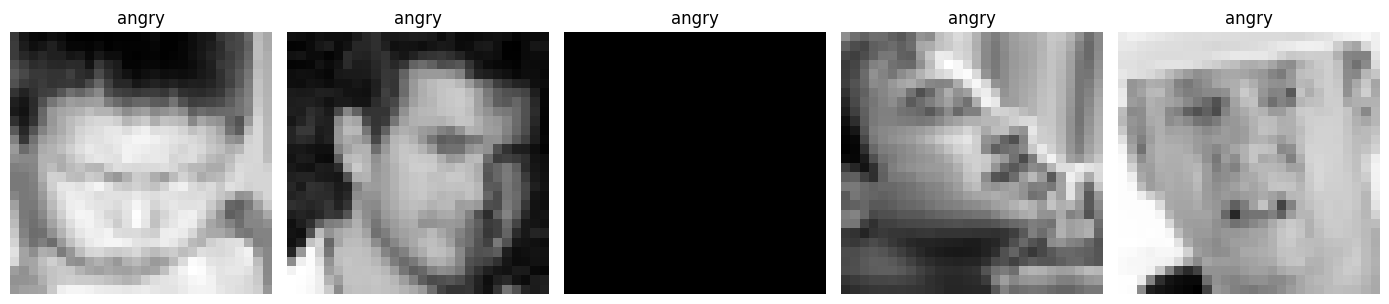

In [12]:
# Hiển thị 5 ảnh đầu tiên và nhãn tương ứng
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for i in range(5):
    img, label_idx = dataset_train[i]
    # Ảnh đã normalize: (img/127.5)-1  ->  khôi phục về [0, 255] để hiển thị
    img_np = ((img + 1) * 127.5).clamp(0, 255).byte().permute(1, 2, 0).numpy()
    axes[i].imshow(img_np, cmap = 'gray')
    axes[i].set_title(idx2label[label_idx])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Xây dựng và khởi tạo mô hình MLP cho bài toán phân loại ảnh

In [13]:
BaseMLP??

Init signature: BaseMLP()
Docstring:     
Helper class that provides a standard way to create an ABC using
inheritance.
Source:        
class BaseMLP(ABC):
    def __init__(self):
        self.Layers = []
        self.model = None
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.criterion = None
    
    @abstractmethod
    def predict(self,X):
        pass
    @abstractmethod
    def get_accuracy(self,logits,y):
        pass
    @abstractmethod
    def compute_loss(self,logits, y):
        pass
    
    def Add_layer(self,layer):
        self.Layers.append(layer)
        # dấu * ở đây có nghĩa là mỗi phần tử của list là 1 tham số của hàm nn.Sequential
        self.model = nn.Sequential(*self.Layers)
    def forward(self,X):
        if self.model is not None:
            return self.model(X)
        raise ValueError("BaseMLP.model is None !")

    def print_fmt(self,Value):
        if Value is None or len(Value) ==0:
            return float('nan')
    

In [14]:
class MLPclassifier(BaseMLP):
    def __init__(self):
        super().__init__()
    def predict(self, X):
        with torch.no_grad():
            logits = self.forward(X)
            return torch.argmax(logits,dim =1)
    def get_accuracy(self, logits, y):
        try:
            return torch.mean((torch.argmax(logits,dim =1) == y).float())
        except:
            return torch.mean((torch.argmax(logits,dim =1) == torch.argmax(y, dim =1)).float())
    def compute_loss(self, logits, y):
        return self.criterion(logits,y)

In [15]:
classifier = MLPclassifier()

In [16]:
input_dims = img.shape[1]*img.shape[2]
print(input_dims)
output_dims = len(classes)
print(output_dims)

784
7


# Xây dựng các Layer cho mô hình MultiLayer Perceptron

In [17]:
# Layer 1 - flatten -> duỗi ảnh thành 1 vector
classifier.Add_layer(nn.Flatten())

# layer 2 
classifier.Add_layer(
    nn.Linear(in_features=input_dims, out_features=256)
)
# layer 3 - activation function
classifier.Add_layer(
    nn.GELU()
)
# Layer 4
classifier.Add_layer(
    nn.Linear(in_features=256,out_features=output_dims)
)

In [18]:
summary(classifier.model, input_size=(1,28,28),batch_size=512, device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [512, 784]               0
            Linear-2                 [512, 256]         200,960
              GELU-3                 [512, 256]               0
            Linear-4                   [512, 7]           1,799
Total params: 202,759
Trainable params: 202,759
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 1.53
Forward/backward pass size (MB): 5.09
Params size (MB): 0.77
Estimated Total Size (MB): 7.39
----------------------------------------------------------------


In [19]:
classifier.model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): GELU(approximate='none')
  (3): Linear(in_features=256, out_features=7, bias=True)
)

In [20]:
# Huấn luyện mô hình 
classifier.fit(dataset=dataset_train,n_epochs=100, optimizer='Adam', batch_size=1024, criterion='CE',validation_split=0.2, verbose=2, is_shuffle=True,lr=0.01)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch [   1/100]


  1%|          | 1/100 [00:12<19:54, 12.06s/it]

Loss = 1.9858 - Accuracy = 0.2670 - Loss_Validation = 1.7097 - Accracy_Validation = 0.3312
Epoch [   2/100]


  2%|▏         | 2/100 [00:26<21:39, 13.26s/it]

...

Loss = 0.2162 - Accuracy = 0.9363 - Loss_Validation = 5.0596 - Accracy_Validation = 0.4248
Epoch [  99/100]


 99%|█████████▉| 99/100 [20:47<00:10, 10.73s/it]

Loss = 0.1713 - Accuracy = 0.9494 - Loss_Validation = 5.0949 - Accracy_Validation = 0.4230
Epoch [ 100/100]


100%|██████████| 100/100 [20:59<00:00, 12.59s/it]

Loss = 0.3291 - Accuracy = 0.9180 - Loss_Validation = 5.4925 - Accracy_Validation = 0.4037


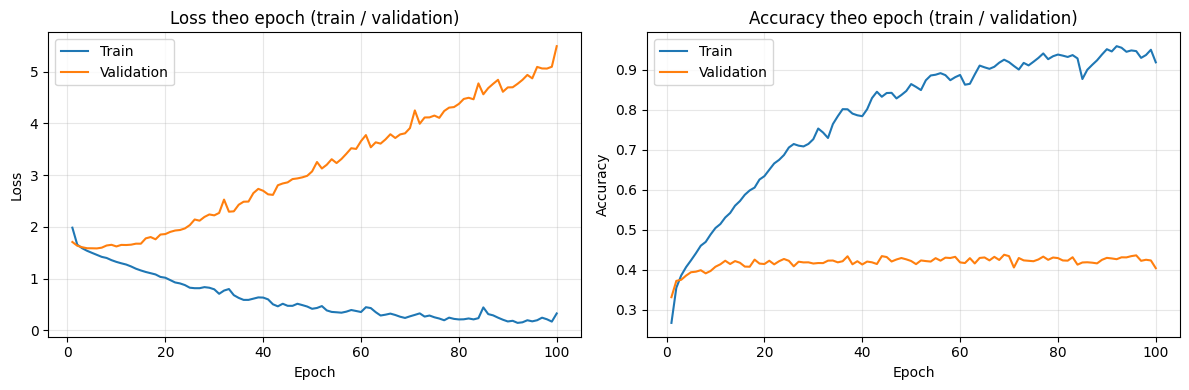

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(classifier.Losses) + 1)

axes[0].plot(epochs, classifier.Losses, label="Train")
if classifier.Val_Losses:
    axes[0].plot(epochs, classifier.Val_Losses, label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss theo epoch (train / validation)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, classifier.Accuracies, label="Train")
if classifier.Val_Accuracies:
    axes[1].plot(epochs, classifier.Val_Accuracies, label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy theo epoch (train / validation)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()